# Autoencoder on MNIST with Gaussian Noise
### Denoising, and similarity scores between original, noisy and reconstructed images

**What this notebook covers**

1. Load MNIST (PyTorch / torchvision) and build train / validation / test loaders
2. Define a **Gaussian-noise** function and **quantify how similar a noisy image is to the original** (SSIM, cosine similarity, Pearson correlation, MSE, PSNR) at several noise levels
3. Implement a **convolutional autoencoder** (encoder → 32-D bottleneck → decoder)
4. Train two models for comparison:
   - **Denoising AE** — input: noisy image, target: clean image
   - **Vanilla AE** — trained on clean images only (never sees noise)
5. Test both on noisy test images; compare similarity of *original ↔ noisy* vs *original ↔ reconstructed*
6. Sweep the noise level, visualise results, inspect the latent space
7. Summary and conclusions

**Similarity metrics used** (all computed between a reference image $a$ and another image $b$, pixels in $[0,1]$):

| Metric | Definition | Better |
|---|---|---|
| MSE | $\frac{1}{N}\sum_i (a_i-b_i)^2$ | lower |
| PSNR | $10\log_{10}\!\big(1/\text{MSE}\big)$ dB | higher |
| Cosine similarity | $\dfrac{a\cdot b}{\lVert a\rVert\,\lVert b\rVert}$ | higher (max 1) |
| Pearson correlation | cosine similarity of the mean-centred images | higher (max 1) |
| SSIM | structural similarity (luminance × contrast × structure, local 7×7 windows) | higher (max 1) |

## 1. Setup

In [1]:
# If needed, uncomment:
# !pip install torch torchvision scikit-image scikit-learn pandas matplotlib

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from skimage.metrics import structural_similarity
from sklearn.decomposition import PCA

# ---------------- configuration ----------------
SEED = 42
LATENT_DIM = 32        # size of the bottleneck
EPOCHS = 15            # training epochs per model
BATCH = 128
LR = 1e-3
TRAIN_SIGMA_MAX = 0.6  # denoising AE sees noise with sigma ~ U(0, 0.6) during training
TEST_SIGMA = 0.4       # main noise level used for the qualitative comparison
N_EVAL = 1000          # number of test images used for similarity metrics (SSIM is the slow one)
# -----------------------------------------------

torch.manual_seed(SEED); np.random.seed(SEED)
device = ("cuda" if torch.cuda.is_available()
          else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
          else "cpu")
plt.rcParams.update({"figure.dpi": 110})
print("Device:", device)

Device: cuda


In [3]:
import ssl, certifi
ssl._create_default_https_context = lambda *a, **k: ssl.create_default_context(cafile=certifi.where())

## 2. Data

In [4]:
tfm = transforms.ToTensor()   # uint8 [0,255] -> float [0,1], shape (1, 28, 28)
train_full = datasets.MNIST("./data", train=True, download=True, transform=tfm)
test_set = datasets.MNIST("./data", train=False, download=True, transform=tfm)

train_set, val_set = random_split(train_full, [54_000, 6_000],
                                  generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=512)
test_loader = DataLoader(test_set, batch_size=512)

# fixed evaluation subset (clean) + labels
X_eval = (test_set.data[:N_EVAL].float() / 255.0).unsqueeze(1)   # (N, 1, 28, 28)
y_eval = test_set.targets[:N_EVAL].numpy()
print(f"train={len(train_set)}  val={len(val_set)}  test={len(test_set)}  eval subset={len(X_eval)}")

100%|██████████| 9.91M/9.91M [00:11<00:00, 887kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 91.0kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 512kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.51MB/s]

train=54000  val=6000  test=10000  eval subset=1000


## 3. Adding Gaussian noise and measuring similarity to the original

We corrupt an image $x\in[0,1]$ with additive white Gaussian noise and clip back to the valid range:

$$\tilde x = \operatorname{clip}\big(x + \varepsilon,\,0,\,1\big),\qquad \varepsilon\sim\mathcal N(0,\sigma^2)$$

Larger $\sigma$ = more corruption. Note that clipping makes the effective noise slightly smaller than $\sigma$ on the black background.

In [5]:
def add_gaussian_noise(x, sigma):
    """x: tensor in [0,1]; sigma: float or tensor broadcastable to x (e.g. shape (B,1,1,1))."""
    return (x + torch.randn_like(x) * sigma).clamp(0.0, 1.0)


def similarity_metrics(ref, other):
    """
    Per-image similarity between `ref` and `other` (tensors of shape (N,1,28,28), values in [0,1]).
    Returns a DataFrame with one row per image and columns MSE, PSNR, Cosine, Pearson, SSIM.
    """
    a = ref.reshape(len(ref), -1).cpu().numpy().astype(np.float64)
    b = other.reshape(len(other), -1).cpu().numpy().astype(np.float64)

    mse = ((a - b) ** 2).mean(axis=1)
    psnr = 10 * np.log10(1.0 / np.maximum(mse, 1e-10))

    cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-12)

    ac, bc = a - a.mean(1, keepdims=True), b - b.mean(1, keepdims=True)
    pear = (ac * bc).sum(1) / (np.linalg.norm(ac, axis=1) * np.linalg.norm(bc, axis=1) + 1e-12)

    ssim = np.array([structural_similarity(a[i].reshape(28, 28), b[i].reshape(28, 28), data_range=1.0)
                     for i in range(len(a))])
    return pd.DataFrame({"MSE": mse, "PSNR": psnr, "Cosine": cos, "Pearson": pear, "SSIM": ssim})

### 3.1 One image at increasing noise levels

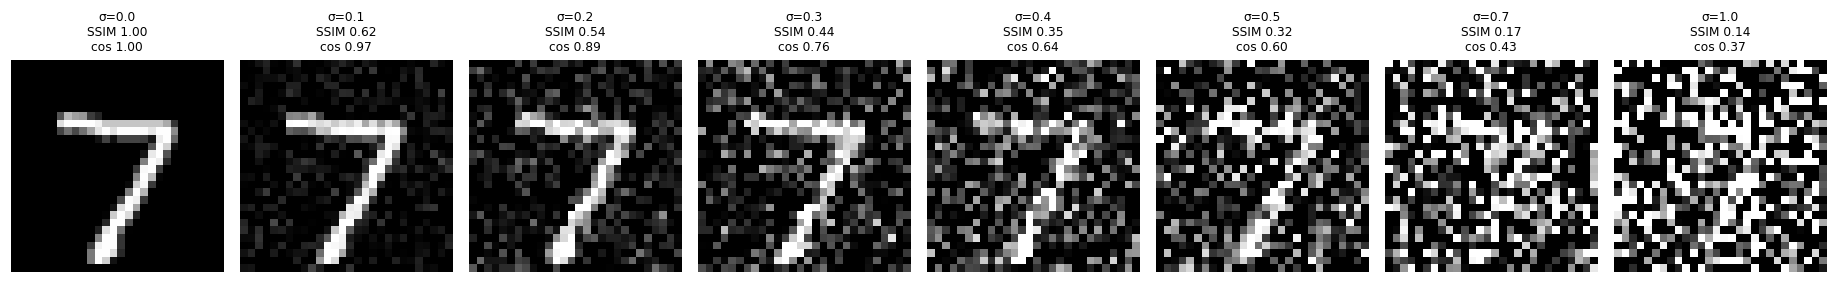

,sigma,MSE,PSNR,Cosine,Pearson,SSIM
0,0.0,0.0000,100.0000,1.0000,1.0000,1.0000
1,0.1,0.0053,22.7309,0.9656,0.9671,0.6229
2,0.2,0.0191,17.1844,0.8865,0.8864,0.5397
3,0.3,0.0477,13.2189,0.7626,0.7388,0.4353
4,0.4,0.0814,10.8932,0.6354,0.5772,0.3490
5,0.5,0.1072,9.6988,0.6008,0.5298,0.3151
6,0.7,0.2051,6.8810,0.4255,0.2917,0.1711
7,1.0,0.2718,5.6572,0.3718,0.2126,0.1419


In [6]:
sigmas_demo = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
img = X_eval[:1]                                   # a single digit
torch.manual_seed(SEED)

fig, axes = plt.subplots(1, len(sigmas_demo), figsize=(2.1 * len(sigmas_demo), 2.7))
rows = []
for ax, s in zip(axes, sigmas_demo):
    noisy = add_gaussian_noise(img, s)
    m = similarity_metrics(img, noisy).iloc[0]
    rows.append({"sigma": s, **m.to_dict()})
    ax.imshow(noisy[0, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"σ={s}\nSSIM {m.SSIM:.2f}\ncos {m.Cosine:.2f}", fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).round(4)

### 3.2 Average similarity of *original ↔ noisy* over the evaluation set

In [7]:
sigmas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8]

base_rows = []
for s in sigmas:
    torch.manual_seed(SEED)
    m = similarity_metrics(X_eval, add_gaussian_noise(X_eval, s)).mean().to_dict()
    base_rows.append({"sigma": s, **m})
noisy_vs_orig = pd.DataFrame(base_rows)
noisy_vs_orig.round(4)

,sigma,MSE,PSNR,Cosine,Pearson,SSIM
0,0.0,0.0000,100.0000,1.0000,1.0000,1.0000
1,0.1,0.0054,22.6681,0.9702,0.9716,0.6818
2,0.2,0.0212,16.7503,0.8929,0.8879,0.5970
3,0.3,0.0466,13.3277,0.7936,0.7669,0.5126
4,0.4,0.0797,10.9967,0.6960,0.6389,0.4312
5,0.5,0.1157,9.3758,0.6154,0.5291,0.3610
6,0.6,0.1503,8.2385,0.5543,0.4438,0.3048
7,0.8,0.2086,6.8138,0.4742,0.3294,0.2268


SSIM, cosine similarity and PSNR all fall as $\sigma$ grows. Pay attention to how **cosine similarity stays high for longer than SSIM**: cosine only looks at the global angle between pixel vectors, whereas SSIM compares local structure and is much more sensitive to noise on the (dominant) black background.

## 4. Convolutional autoencoder

```
Input 1×28×28
  → Conv(32, 3×3, stride 2) + ReLU     → 32×14×14
  → Conv(64, 3×3, stride 2) + ReLU     → 64×7×7
  → Flatten → Linear                   → latent z (32-D)        ← bottleneck
  → Linear + ReLU → reshape            → 64×7×7
  → ConvTranspose(32, stride 2) + ReLU → 32×14×14
  → ConvTranspose(1,  stride 2) + Sigmoid → 1×28×28
```

The 784 → 32 bottleneck forces the network to keep only the essential structure of a digit; random pixel noise is not compressible, so it tends to be discarded. Loss: pixel-wise MSE between the reconstruction and the **clean** image.

In [8]:
class ConvAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),     # 14x14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),    # 7x7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim),
        )
        self.decoder_fc = nn.Sequential(nn.Linear(latent_dim, 64 * 7 * 7), nn.ReLU())
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 14x14
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid() # 28x28
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(self.decoder_fc(z).view(-1, 64, 7, 7))

    def forward(self, x):
        return self.decode(self.encode(x))


m = ConvAE().to(device)
print(m)
print("Parameters:", sum(p.numel() for p in m.parameters()))
assert m(torch.zeros(2, 1, 28, 28, device=device)).shape == (2, 1, 28, 28)

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=3136, out_features=32, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=32, out_features=3136, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)
Parameters: 241441


## 5. Training

`sigma_max` controls the training input:

- `sigma_max > 0` → **denoising AE**: every image in a batch gets its own noise level $\sigma\sim U(0,\sigma_{max})$ (so the model generalises across noise levels); target = clean image.
- `sigma_max = 0` → **vanilla AE**: input = target = clean image.

In [9]:
def run_epoch(model, loader, optimizer, sigma_max, train):
    model.train(train)
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for x, _ in loader:
            x = x.to(device)
            if sigma_max > 0:
                s = torch.rand(x.size(0), 1, 1, 1, device=device) * sigma_max   # per-image sigma
                inp = add_gaussian_noise(x, s)
            else:
                inp = x
            loss = F.mse_loss(model(inp), x)          # compare with the CLEAN image
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * x.size(0); n += x.size(0)
    return total / n


def fit(model, sigma_max, epochs=EPOCHS, name="model"):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    hist = {"train": [], "val": []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, opt, sigma_max, train=True)
        va = run_epoch(model, val_loader, opt, sigma_max, train=False)
        hist["train"].append(tr); hist["val"].append(va)
        print(f"[{name}] epoch {ep:>2}/{epochs}  train MSE {tr:.5f}  val MSE {va:.5f}  ({time.time()-t0:.0f}s)")
    return hist

In [10]:
torch.manual_seed(SEED)
dae = ConvAE().to(device)
hist_dae = fit(dae, sigma_max=TRAIN_SIGMA_MAX, name="Denoising AE")

[Denoising AE] epoch  1/15  train MSE 0.04644  val MSE 0.01786  (7s)
[Denoising AE] epoch  2/15  train MSE 0.01467  val MSE 0.01290  (15s)
[Denoising AE] epoch  3/15  train MSE 0.01206  val MSE 0.01136  (23s)
[Denoising AE] epoch  4/15  train MSE 0.01084  val MSE 0.01059  (31s)
[Denoising AE] epoch  5/15  train MSE 0.01019  val MSE 0.00993  (42s)
[Denoising AE] epoch  6/15  train MSE 0.00975  val MSE 0.00955  (50s)
[Denoising AE] epoch  7/15  train MSE 0.00941  val MSE 0.00943  (57s)
[Denoising AE] epoch  8/15  train MSE 0.00915  val MSE 0.00905  (66s)
[Denoising AE] epoch  9/15  train MSE 0.00895  val MSE 0.00893  (75s)
[Denoising AE] epoch 10/15  train MSE 0.00877  val MSE 0.00879  (83s)
[Denoising AE] epoch 11/15  train MSE 0.00862  val MSE 0.00869  (91s)
[Denoising AE] epoch 12/15  train MSE 0.00848  val MSE 0.00852  (99s)
[Denoising AE] epoch 13/15  train MSE 0.00840  val MSE 0.00847  (118s)
[Denoising AE] epoch 14/15  train MSE 0.00831  val MSE 0.00842  (144s)
[Denoising AE] epoc

In [11]:
torch.manual_seed(SEED)
vae_model = ConvAE().to(device)          # "vanilla" AE trained on clean images only
hist_vae = fit(vae_model, sigma_max=0.0, name="Vanilla AE")

[Vanilla AE] epoch  1/15  train MSE 0.04084  val MSE 0.01231  (26s)
[Vanilla AE] epoch  2/15  train MSE 0.00957  val MSE 0.00812  (42s)
[Vanilla AE] epoch  3/15  train MSE 0.00734  val MSE 0.00690  (50s)
[Vanilla AE] epoch  4/15  train MSE 0.00643  val MSE 0.00619  (58s)
[Vanilla AE] epoch  5/15  train MSE 0.00587  val MSE 0.00577  (66s)
[Vanilla AE] epoch  6/15  train MSE 0.00550  val MSE 0.00546  (75s)
[Vanilla AE] epoch  7/15  train MSE 0.00521  val MSE 0.00522  (84s)
[Vanilla AE] epoch  8/15  train MSE 0.00499  val MSE 0.00512  (92s)
[Vanilla AE] epoch  9/15  train MSE 0.00480  val MSE 0.00485  (100s)
[Vanilla AE] epoch 10/15  train MSE 0.00465  val MSE 0.00471  (109s)
[Vanilla AE] epoch 11/15  train MSE 0.00450  val MSE 0.00461  (118s)
[Vanilla AE] epoch 12/15  train MSE 0.00440  val MSE 0.00453  (127s)
[Vanilla AE] epoch 13/15  train MSE 0.00430  val MSE 0.00444  (135s)
[Vanilla AE] epoch 14/15  train MSE 0.00422  val MSE 0.00436  (143s)
[Vanilla AE] epoch 15/15  train MSE 0.0041

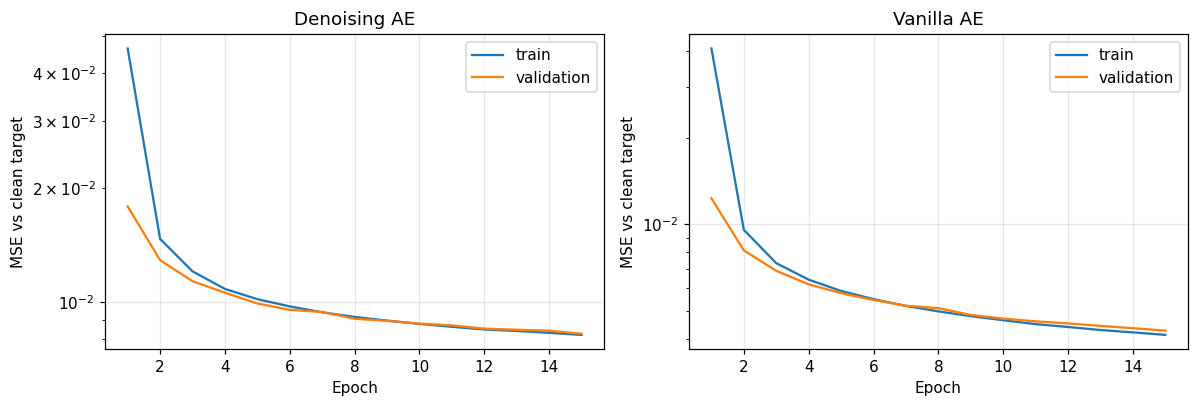

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, (h, title) in zip(ax, [(hist_dae, "Denoising AE"), (hist_vae, "Vanilla AE")]):
    a.plot(range(1, EPOCHS + 1), h["train"], label="train"); a.plot(range(1, EPOCHS + 1), h["val"], label="validation")
    a.set(title=title, xlabel="Epoch", ylabel="MSE vs clean target", yscale="log"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# torch.save(dae.state_dict(), "denoising_ae.pt"); torch.save(vae_model.state_dict(), "vanilla_ae.pt")

## 6. Testing on noisy MNIST images

In [13]:
@torch.no_grad()
def reconstruct(model, x, bs=500):
    model.eval()
    return torch.cat([model(x[i:i + bs].to(device)).cpu() for i in range(0, len(x), bs)])


torch.manual_seed(SEED)
X_noisy = add_gaussian_noise(X_eval, TEST_SIGMA)
rec_dae = reconstruct(dae, X_noisy)
rec_vae = reconstruct(vae_model, X_noisy)

per_image = {
    "Noisy input": similarity_metrics(X_eval, X_noisy),
    "Vanilla AE output": similarity_metrics(X_eval, rec_vae),
    "Denoising AE output": similarity_metrics(X_eval, rec_dae),
}
summary = pd.DataFrame({k: v.mean() for k, v in per_image.items()}).T
print(f"Similarity to the ORIGINAL clean image  (σ = {TEST_SIGMA}, {N_EVAL} test images, mean over images)")
summary.round(4)

Similarity to the ORIGINAL clean image  (σ = 0.4, 1000 test images, mean over images)


,MSE,PSNR,Cosine,Pearson,SSIM
Noisy input,0.0797,10.9967,0.6960,0.6389,0.4312
Vanilla AE output,0.0765,11.2313,0.6696,0.6081,0.3379
Denoising AE output,0.0091,20.8692,0.9521,0.9442,0.8837


### 6.1 Visual comparison

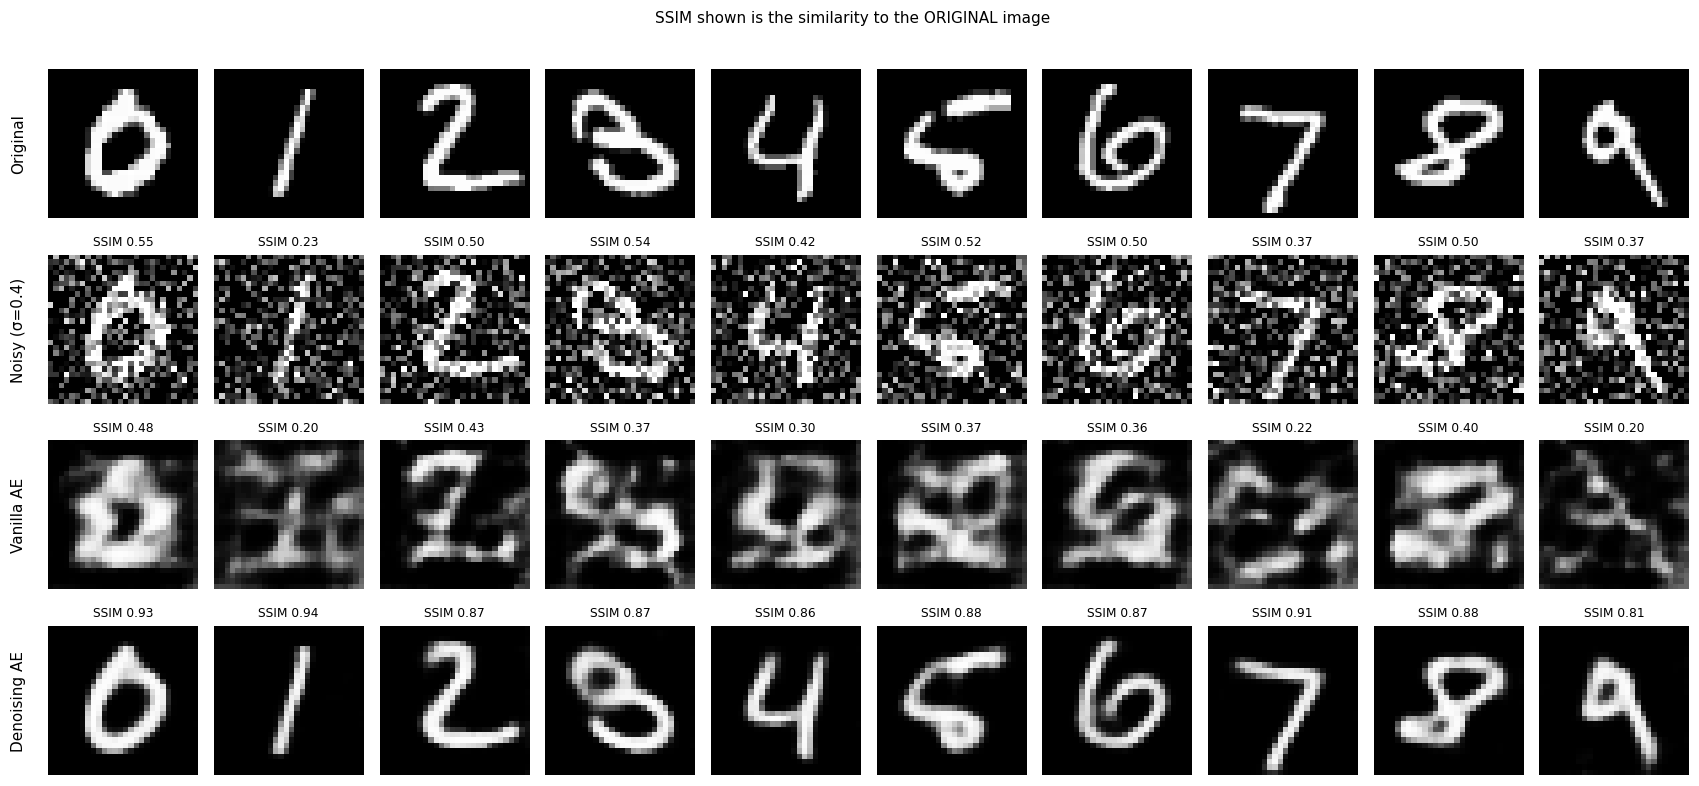

In [14]:
n_show = 10
ids = [int(np.where(y_eval == d)[0][0]) for d in range(n_show)]       # one image per digit
rows = [("Original", X_eval, None),
        (f"Noisy (σ={TEST_SIGMA})", X_noisy, per_image["Noisy input"]),
        ("Vanilla AE", rec_vae, per_image["Vanilla AE output"]),
        ("Denoising AE", rec_dae, per_image["Denoising AE output"])]

fig, axes = plt.subplots(len(rows), n_show, figsize=(1.55 * n_show, 1.8 * len(rows)))
for r, (name, imgs, df) in enumerate(rows):
    for c, i in enumerate(ids):
        axes[r, c].imshow(imgs[i, 0], cmap="gray", vmin=0, vmax=1); axes[r, c].axis("off")
        if df is not None:
            axes[r, c].set_title(f"SSIM {df.SSIM[i]:.2f}", fontsize=8)
    axes[r, 0].text(-0.15, 0.5, name, transform=axes[r, 0].transAxes, rotation=90, va="center", ha="right", fontsize=10)
plt.suptitle("SSIM shown is the similarity to the ORIGINAL image", y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

### 6.2 Distribution of per-image SSIM and pixel-error maps

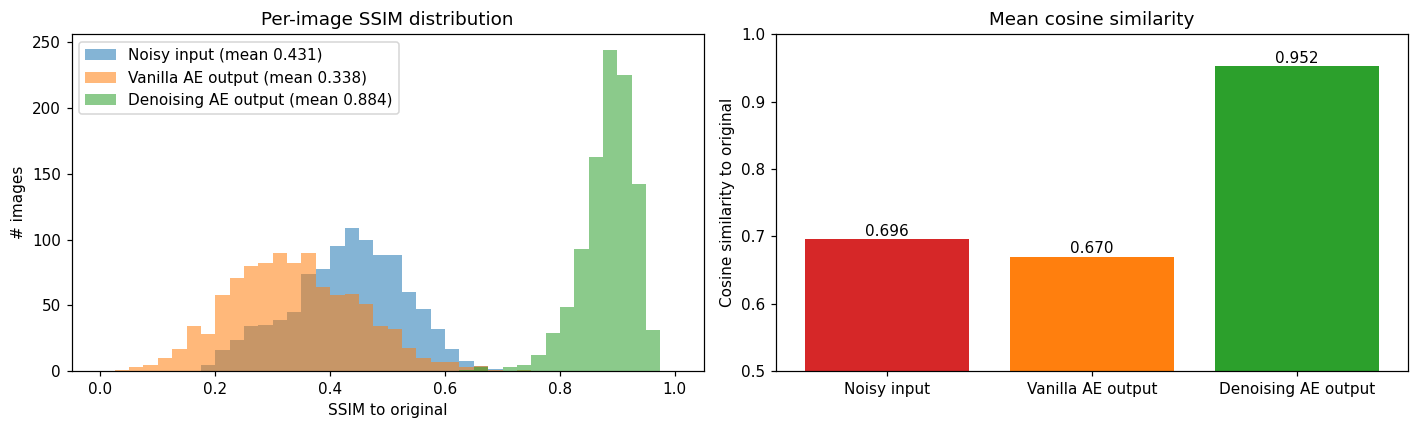

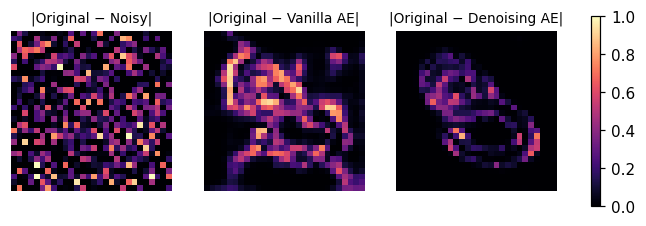

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, 1, 41)
for name, df in per_image.items():
    ax[0].hist(df.SSIM, bins=bins, alpha=0.55, label=f"{name} (mean {df.SSIM.mean():.3f})")
ax[0].set(xlabel="SSIM to original", ylabel="# images", title="Per-image SSIM distribution"); ax[0].legend()

ax[1].bar(summary.index, summary["Cosine"], color=["tab:red", "tab:orange", "tab:green"])
ax[1].set(ylim=(min(0.5, summary["Cosine"].min() - 0.05), 1.0), ylabel="Cosine similarity to original", title="Mean cosine similarity")
for i, v in enumerate(summary["Cosine"]): ax[1].text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

# absolute error maps for one example
i = ids[3]
fig, axes = plt.subplots(1, 3, figsize=(8, 2.8))
for a, (name, imgs) in zip(axes, [("|Original − Noisy|", X_noisy), ("|Original − Vanilla AE|", rec_vae), ("|Original − Denoising AE|", rec_dae)]):
    im = a.imshow((X_eval[i, 0] - imgs[i, 0]).abs(), cmap="magma", vmin=0, vmax=1); a.set_title(name, fontsize=9); a.axis("off")
plt.colorbar(im, ax=axes, shrink=0.8); plt.show()

## 7. Robustness: sweeping the noise level

How do the similarity scores of the noisy input and of both autoencoder outputs change as $\sigma$ grows? The denoising AE was trained with $\sigma \le 0.6$, so $\sigma = 0.8$ tests **extrapolation** beyond the training range.

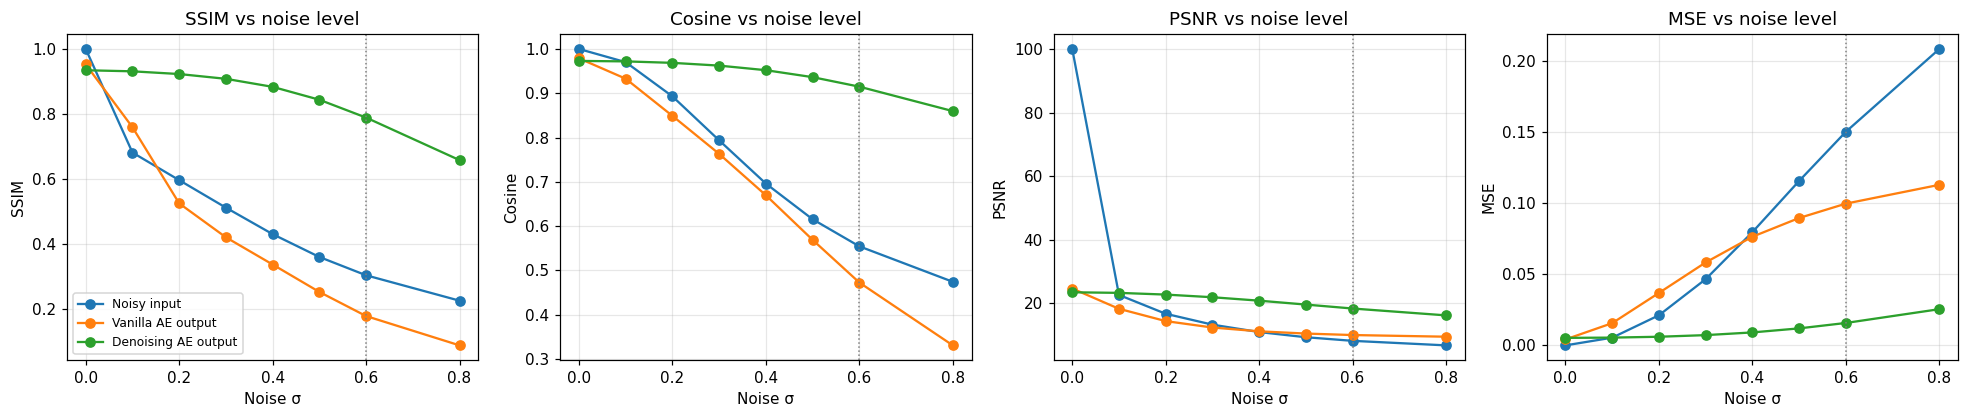

,Denoising AE output,Noisy input,Vanilla AE output
sigma,,,
0.0,0.935,1.000,0.953
0.1,0.931,0.682,0.760
0.2,0.923,0.597,0.526
0.3,0.908,0.513,0.421
0.4,0.884,0.431,0.338
0.5,0.844,0.361,0.254
0.6,0.789,0.305,0.180
0.8,0.659,0.227,0.090


In [16]:
sweep_rows = []
for s in sigmas:
    torch.manual_seed(SEED)
    noisy = add_gaussian_noise(X_eval, s)
    for label, imgs in [("Noisy input", noisy),
                        ("Vanilla AE output", reconstruct(vae_model, noisy)),
                        ("Denoising AE output", reconstruct(dae, noisy))]:
        sweep_rows.append({"sigma": s, "image": label, **similarity_metrics(X_eval, imgs).mean().to_dict()})
sweep = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 4, figsize=(18, 3.9))
for ax, metric in zip(axes, ["SSIM", "Cosine", "PSNR", "MSE"]):
    for label, g in sweep.groupby("image", sort=False):
        ax.plot(g.sigma, g[metric], "o-", label=label)
    ax.axvline(TRAIN_SIGMA_MAX, color="grey", ls=":", lw=1)
    ax.set(xlabel="Noise σ", ylabel=metric, title=f"{metric} vs noise level"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

sweep.pivot(index="sigma", columns="image", values="SSIM").round(3).rename_axis(columns=None)

## 8. What does the latent space look like?

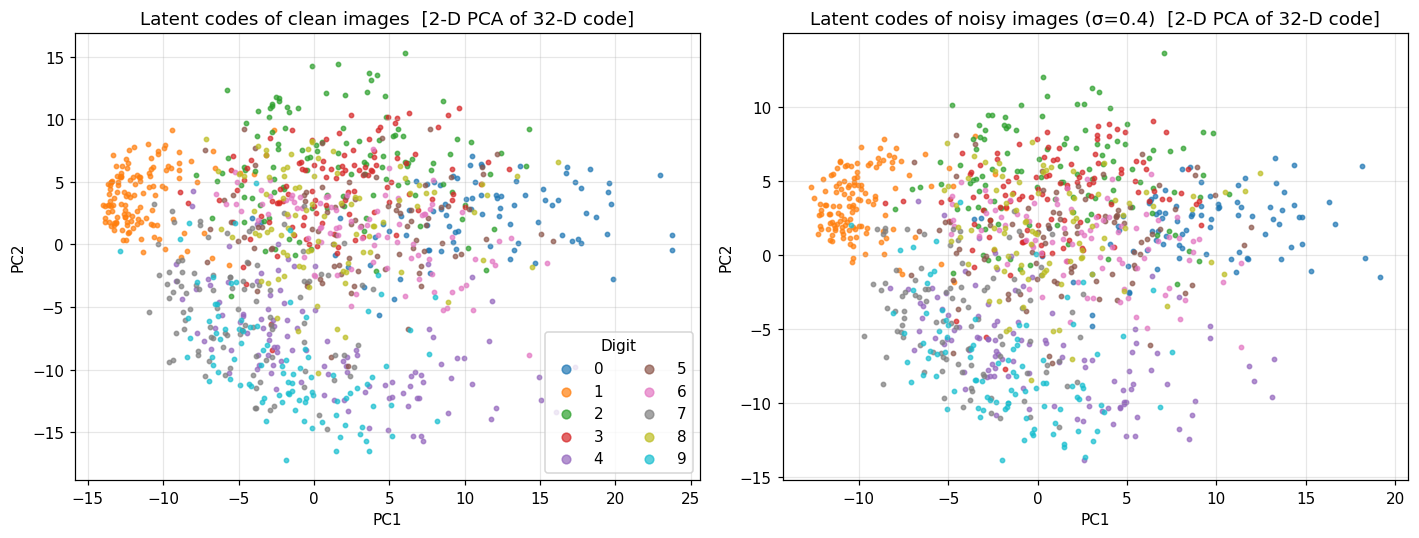

Mean relative shift of the latent code caused by noise: 0.270


In [17]:
with torch.no_grad():
    dae.eval()
    Z = dae.encode(X_eval.to(device)).cpu().numpy()                 # latent codes of CLEAN test images
    Zn = dae.encode(X_noisy.to(device)).cpu().numpy()               # latent codes of NOISY test images

pca2 = PCA(n_components=2).fit(Z)
P, Pn = pca2.transform(Z), pca2.transform(Zn)
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (pts, title) in zip(ax, [(P, "Latent codes of clean images"), (Pn, f"Latent codes of noisy images (σ={TEST_SIGMA})")]):
    for d in range(10):
        m = y_eval == d
        a.scatter(pts[m, 0], pts[m, 1], s=8, color=cmap(d), label=str(d), alpha=0.7)
    a.set(title=title + "  [2-D PCA of 32-D code]", xlabel="PC1", ylabel="PC2"); a.grid(alpha=0.3)
ax[0].legend(ncol=2, markerscale=2, title="Digit")
plt.tight_layout(); plt.show()

drift = np.linalg.norm(Z - Zn, axis=1).mean() / np.linalg.norm(Z, axis=1).mean()
print(f"Mean relative shift of the latent code caused by noise: {drift:.3f}")

## 9. Final summary

In [18]:
final = summary.copy()
final["ΔSSIM vs noisy"] = final["SSIM"] - final.loc["Noisy input", "SSIM"]
final["ΔPSNR vs noisy (dB)"] = final["PSNR"] - final.loc["Noisy input", "PSNR"]
final.round(4)

,MSE,PSNR,Cosine,Pearson,SSIM,ΔSSIM vs noisy,ΔPSNR vs noisy (dB)
Noisy input,0.0797,10.9967,0.6960,0.6389,0.4312,0.0000,0.0000
Vanilla AE output,0.0765,11.2313,0.6696,0.6081,0.3379,-0.0933,0.2346
Denoising AE output,0.0091,20.8692,0.9521,0.9442,0.8837,0.4525,9.8725


## 10. Conclusions

- **Noise quantified.** SSIM, cosine similarity and PSNR between the original and the noisy image decrease monotonically with $\sigma$; SSIM degrades fastest because it is sensitive to local structure, while cosine similarity is dominated by the bright strokes.
- **Denoising AE.** Trained to map noisy → clean through a 32-D bottleneck, it should recover a large part of the lost similarity: expect clearly higher SSIM/PSNR/cosine than the noisy input at $\sigma = 0.4$ (see the summary table for the exact numbers from your run).
- **Vanilla AE.** Trained only on clean images, it was never asked to ignore noise. The bottleneck still removes some of it, but it is typically worse than the denoising AE, and it can produce distorted digits when the input is far from the clean distribution. This illustrates that *training with corrupted inputs* — not just the bottleneck — is what makes an autoencoder a good denoiser.
- **Generalisation.** Performance drops for $\sigma$ beyond the training range (the dotted line in the sweep plots), so the training-noise range should cover the noise expected at test time.
- **Latent space.** The 32-D codes of clean and noisy images should land in similar regions with the digit classes still largely separable if the model has learned a noise-robust representation (check the plots and the printed latent shift for your run).

**Ideas to extend:** vary `LATENT_DIM` (4 / 16 / 64) and plot SSIM vs bottleneck size; try a U-Net-style skip-connection model; use an SSIM or L1 + SSIM loss; test other corruptions (salt-and-pepper, Poisson); compare with the PCA denoiser from the companion notebook at the same code size.